## 12.2 K-평균 군집화 맛보기 : 인위적으로 만든 데이터셋


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_url = 'https://raw.githubusercontent.com/snkn1959/data_source/main/example_cluster.csv'
data = pd.read_csv(file_url)

In [2]:
data

,var_1,var_2
0,3.264413,6.929164
1,0.220814,2.251631
2,-8.786197,-8.333582
3,-0.008547,2.630791
4,4.912903,6.888520
...,...,...
995,4.678232,7.704404
996,5.250715,6.930948
997,-11.818752,-5.609853
998,0.613725,3.809334


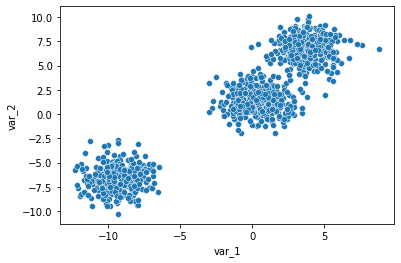

In [ ]:
sns.scatterplot(x='var_1', y = 'var_2', data= data)

In [3]:
from sklearn.cluster import KMeans

In [4]:
kmeans_model = KMeans(n_clusters=3, random_state = 100)

In [5]:
kmeans_model.fit(data)

KMeans(n_clusters=3, random_state=100)

In [6]:
kmeans_model.predict(data)

array([2, 1, 0, 1, 2, 1, 2, 0, 2, 2, 2, 2, 1, 2, 0, 1, 0, 2, 2, 0, 1, 0,
       0, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 2, 0, 0, 2, 2, 2, 1, 1, 2, 1,
       0, 2, 2, 1, 0, 1, 2, 0, 2, 1, 2, 0, 0, 0, 1, 1, 1, 2, 1, 2, 0, 2,
       1, 0, 2, 0, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 0, 1, 2, 2, 1, 2,
       0, 1, 2, 1, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0, 0, 1, 0, 2, 0, 0, 0, 2,
       0, 1, 2, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 0, 1, 0, 1, 0, 2, 2, 0, 2,
       1, 2, 0, 2, 1, 1, 1, 2, 1, 2, 0, 0, 1, 2, 0, 1, 1, 2, 2, 1, 1, 2,
       2, 2, 1, 0, 2, 0, 2, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 2, 0,
       1, 2, 0, 1, 1, 0, 1, 1, 2, 2, 2, 1, 2, 0, 1, 1, 1, 0, 2, 1, 1, 1,
       2, 2, 2, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 2, 1, 2, 1, 0, 0, 2, 1, 0,
       1, 1, 0, 2, 0, 0, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 1, 0,
       2, 0, 0, 2, 1, 0, 2, 2, 0, 2, 1, 0, 2, 1, 0, 0, 1, 0, 2, 0, 2, 1,
       1, 1, 0, 2, 1, 2, 2, 2, 2, 0, 2, 0, 1, 1, 2, 0, 1, 0, 2, 0, 1, 1,
       1, 1, 1, 0, 1, 2, 1, 2, 1, 2, 0, 1, 0, 1, 1,

In [7]:
data['label'] = kmeans_model.predict(data)

<Axes: xlabel='var_1', ylabel='var_2'>

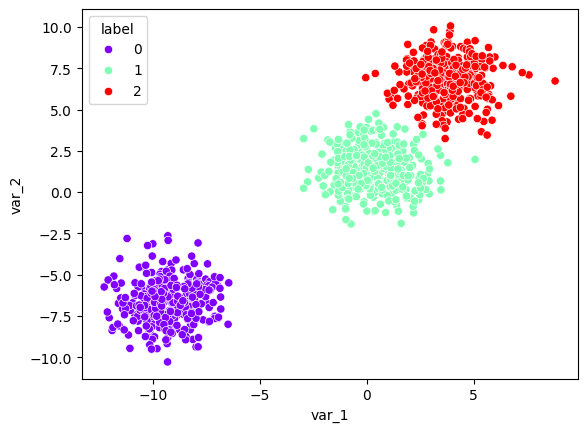

In [8]:
sns.scatterplot(x='var_1', y = 'var_2', data= data, hue='label', palette='rainbow')

In [9]:
kmeans_model.inertia_

3090.033237076663

In [10]:
temp_model = KMeans(n_clusters=500, random_state = 100)
temp_model.fit(data)
temp_model.inertia_

6.3412059092392274

In [11]:
distance = []   # ❶
for k in range(2,10):
    k_model = KMeans(n_clusters=k)
    k_model.fit(data)
    distance.append(k_model.inertia_) # ❷

In [12]:
distance

[9908.551424778409,
 3090.033237076663,
 2770.831965101692,
 2488.139686458968,
 2065.223415928972,
 2133.04190030367,
 1618.057379545756,
 1532.1623578745086]

<Axes: >

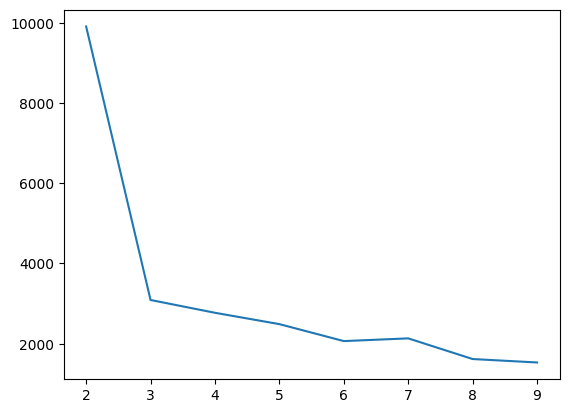

In [13]:
sns.lineplot(x=range(2,10), y=distance)

## 12.3 데이터 불러오기 및 데이터 확인하기 : 고객 데이터셋


In [14]:
file_url = 'https://raw.githubusercontent.com/snkn1959/data_source/main/customer.csv'
customer = pd.read_csv(file_url)

In [15]:
customer.head()

,cc_num,category,amt
0,2703186189652095,misc,4.97
1,630423337322,grocery,107.23
2,38859492057661,entertainment,220.11
3,3534093764340240,gas_transport,45.00
4,375534208663984,misc,41.96


In [16]:
customer['cc_num'].nunique()

100

## 12.4 전처리 : 피처 엔지니어링


In [17]:
customer_dummy = pd.get_dummies(customer, columns =['category'])

In [18]:
customer_dummy.head()

,cc_num,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel
0,2703186189652095,4.97,False,False,False,False,False,False,False,True,False,False,False
1,630423337322,107.23,False,False,False,True,False,False,False,False,False,False,False
2,38859492057661,220.11,True,False,False,False,False,False,False,False,False,False,False
3,3534093764340240,45.00,False,False,True,False,False,False,False,False,False,False,False
4,375534208663984,41.96,False,False,False,False,False,False,False,True,False,False,False


In [19]:
cat_list = customer_dummy.columns[2:]

In [20]:
for i in cat_list:
    customer_dummy[i] = customer_dummy[i] * customer_dummy['amt']

In [21]:
customer_dummy

,cc_num,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel
0,2703186189652095,4.97,0.00,0.0,0.0,0.00,0.00,0.0,0.0,4.97,0.0,0.00,0.0
1,630423337322,107.23,0.00,0.0,0.0,107.23,0.00,0.0,0.0,0.00,0.0,0.00,0.0
2,38859492057661,220.11,220.11,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0
3,3534093764340240,45.00,0.00,0.0,45.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0
4,375534208663984,41.96,0.00,0.0,0.0,0.00,0.00,0.0,0.0,41.96,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240449,4716561796955522,4.93,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,4.93,0.0
240450,30074693890476,140.12,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,140.12,0.0
240451,30404291151692,37.79,0.00,0.0,0.0,0.00,37.79,0.0,0.0,0.00,0.0,0.00,0.0
240452,4922710831011201,17.50,17.50,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0


In [22]:
customer_agg = customer_dummy.groupby('cc_num').sum()

In [23]:
customer_agg.head()

,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel
cc_num,,,,,,,,,,,,
60495593109,48149.62,3169.74,4043.46,5076.36,7576.58,1631.22,5458.58,4924.97,4889.57,3135.25,8106.36,137.53
571365235126,259784.87,13864.51,9055.51,36525.79,48812.73,13685.60,19342.79,17726.82,32542.61,16672.08,45994.60,5561.83
571465035400,270081.63,16162.98,15448.75,9081.62,41643.82,15244.03,28282.98,13737.95,15880.82,8771.27,59454.96,46372.45
630412733309,41959.52,3212.46,1543.16,5786.98,8416.70,3201.04,2474.68,3648.97,3109.83,2592.17,7586.79,386.74
630423337322,244612.73,12786.75,6905.07,36460.40,43854.26,12136.74,21106.87,16807.24,32400.76,15885.32,44287.02,1982.30


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # ❶
scaled_df = pd.DataFrame(scaler.fit_transform(customer_agg), # ❷
            columns = customer_agg.columns, # ❸
            index=customer_agg.index) # ❹


In [25]:
scaled_df.head()

,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel
cc_num,,,,,,,,,,,,
60495593109,-1.402327,-1.135617,-0.971069,-1.000180,-1.118217,-1.561756,-1.145051,-1.276913,-1.124693,-1.070260,-1.141424,-0.619930
571365235126,1.079407,0.414075,0.168880,2.090013,0.767268,1.040236,0.844969,1.127922,1.210503,1.807350,0.659967,-0.222587
571465035400,1.200151,0.747127,1.622968,-0.606627,0.439476,1.376630,2.126364,0.378610,-0.196523,0.127825,1.299938,2.766891
630412733309,-1.474915,-1.129427,-1.539741,-0.930355,-1.079803,-1.222903,-1.572733,-1.516610,-1.274986,-1.185705,-1.166127,-0.601675
630423337322,0.901491,0.257905,-0.320220,2.083588,0.540547,0.705908,1.097814,0.955178,1.198524,1.640103,0.578781,-0.484796


## 12.5 고객 데이터 모델링 및 실루엣 계수

<Axes: >

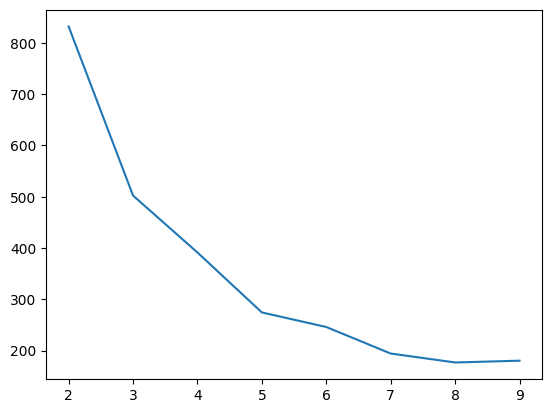

In [26]:
distance = []
for k in range(2,10):
    k_model = KMeans(n_clusters=k)
    k_model.fit(scaled_df)
    labels = k_model.predict(scaled_df)
    distance.append(k_model.inertia_)

sns.lineplot(x=range(2,10), y=distance)

In [27]:
from sklearn.metrics import silhouette_score

In [28]:
silhouette = []
for k in range(2,10):
    k_model = KMeans(n_clusters=k)
    k_model.fit(scaled_df)
    labels = k_model.predict(scaled_df)
    silhouette.append(silhouette_score(scaled_df, labels))

<Axes: >

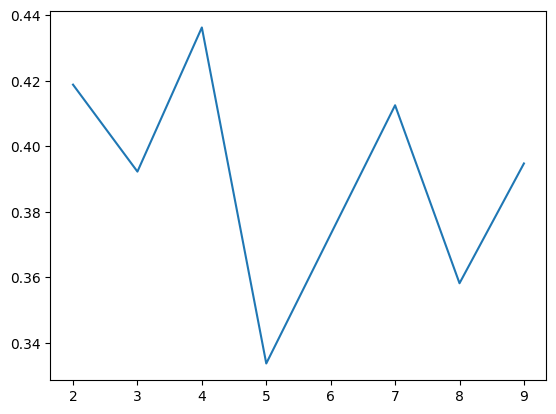

In [29]:
sns.lineplot(x=range(2,10), y=silhouette)

## 12.6 최종 예측 모델 및 결과 해석


In [30]:
k_model = KMeans(n_clusters=4)
k_model.fit(scaled_df)
labels = k_model.predict(scaled_df)

In [31]:
scaled_df['label'] = labels

In [32]:
scaled_df_mean = scaled_df.groupby('label').mean() # ❶
scaled_df_count = scaled_df.groupby('label').count()['category_travel'] # ❷

In [33]:
scaled_df_count = scaled_df_count.rename('count')

In [34]:
scaled_df_all = scaled_df_mean.join(scaled_df_count)

In [35]:
scaled_df_all

,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel,count
label,,,,,,,,,,,,,
0,-0.233007,-0.378817,1.490523,-0.037940,-0.351214,-1.023571,0.075900,1.297310,-0.200653,-0.019432,-0.544285,-0.331132,4
1,-1.059521,-0.895448,-0.854596,-0.839815,-0.769481,-1.167157,-1.061021,-1.056107,-0.834534,-0.914922,-0.828505,-0.365976,32
2,1.309915,1.235541,1.090087,0.508856,1.091560,1.144394,1.092751,1.048955,1.137577,1.095257,1.261472,0.415308,27
3,-0.014352,-0.086216,-0.217496,0.359100,-0.093078,0.284991,0.112021,0.007686,-0.086673,-0.005857,-0.145147,0.049256,37
